In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,BatchNormalization

In [2]:
# In this notebook we will look how come batch normalization effects the model performance and improves it 

In [3]:
# Basically from pov we always used to do normalization for faster convergence in ann models beforehand ,
# now we take it even one step further and now the outputs from the neurons of a layer is also normalized when sent to another , so we converge 
# even faster

In [ ]:
# The setup will be simple we will be using a concentric cirles dataset and train the model with and 
# without batch normalization to look for performance

In [5]:
# Creating the dataset

In [68]:
X, y = make_circles(n_samples=500, factor=0.45, noise=0.175, random_state=42)

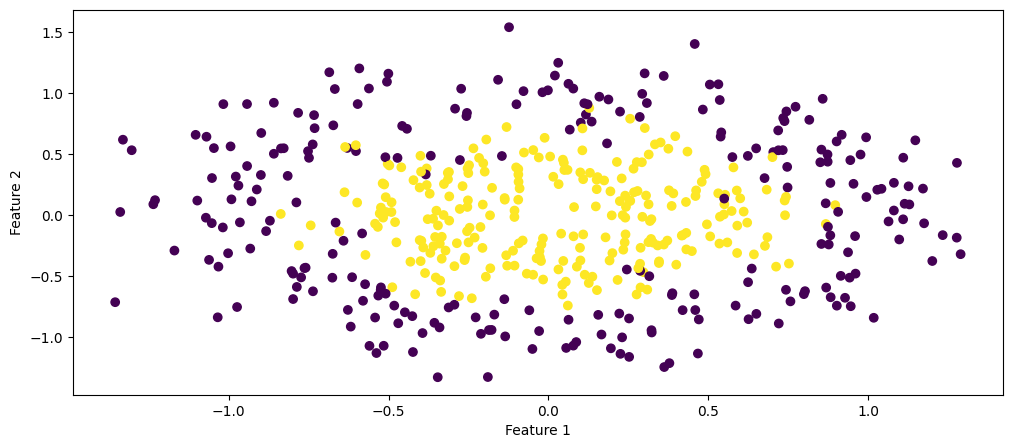

In [69]:
# Now let's visualize it 
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [71]:
# Now model training without batch normalization

In [72]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [73]:
# Now let's skim the summary to know what amount of parameters we are dealing with
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy']) # Model compiling

In [75]:
# Now lets run the model
history_1 = model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5375 - loss: 0.6911 - val_accuracy: 0.5300 - val_loss: 0.6882
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5200 - loss: 0.6870 - val_accuracy: 0.5800 - val_loss: 0.6844
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5300 - loss: 0.6832 - val_accuracy: 0.5900 - val_loss: 0.6806
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5125 - loss: 0.6794 - val_accuracy: 0.5900 - val_loss: 0.6765
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5175 - loss: 0.6753 - val_accuracy: 0.6000 - val_loss: 0.6725
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5425 - loss: 0.6710 - val_accuracy: 0.6100 - val_loss: 0.6679
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5550 - loss: 0.6660 - val_accuracy: 0.5900 - val_loss: 0.6628
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5925 - loss: 0.6612 - val_accuracy: 0.6400 - val_l

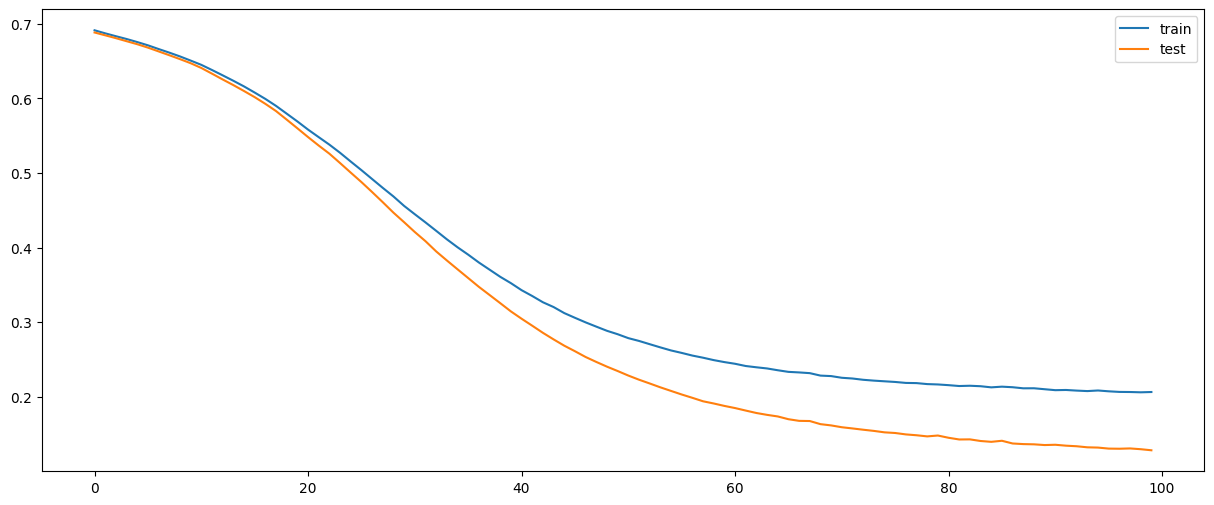

In [76]:
# Also now let's plot the loss and val_loss to understand what happened
plt.figure(figsize=(15,6))
plt.plot(history_1.history['loss'],label='train')
plt.plot(history_1.history['val_loss'],label='test')
plt.legend()
plt.show()

28125/28125 ━━━━━━━━━━━━━━━━━━━━ 58s 2ms/step


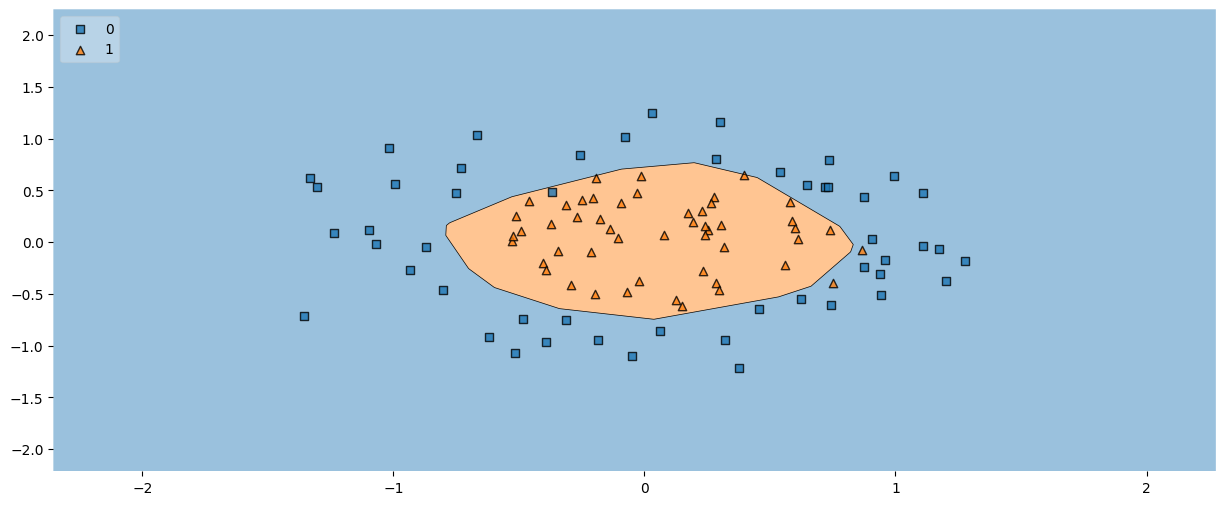

In [77]:
# Now let's checkout the model performance by plotting it's boundary using plot_decision_regions
plt.figure(figsize=(15,6))
plot_decision_regions(X_test,y_test,clf=model,legend=2)
plt.show()

In [78]:
# As we can see the amount of loss across epoch is gradual and that also , model seems to overfit a bit in the training stage 